# Avaliação A3 - Detecção de Fraude com Rede Neural

Universidade São Judas Tadeu  
Disciplina: Inteligência Artificial

Este notebook inicia o projeto prático de comitê de classificadores. Nesta primeira etapa, ele realiza a limpeza/pre-processamento da base e treina um modelo de rede neural para classificar transações fraudulentas.

## 1. Importação das bibliotecas

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.20
sns.set_theme(style="whitegrid")

## 2. Carregamento da base de dados

In [7]:
DATA_PATH = Path("data") / "synthetic_fraud_dataset.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,9608,363,4922.587542,ATM,Travel,TR,12,0.992347,0.947908,1
1,456,692,48.018303,QR,Food,US,21,0.168571,0.224057,0
2,4747,587,136.881960,Online,Travel,TR,14,0.296127,0.125058,0
3,6934,445,80.534719,POS,Clothing,TR,23,0.124801,0.159243,0
4,1646,729,120.041158,Online,Grocery,FR,16,0.098129,0.027542,0


## 3. Análise exploratória inicial

In [8]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

df.info()

Linhas: 10000
Colunas: 10
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   amount             10000 non-null  float64
 3   transaction_type   10000 non-null  str    
 4   merchant_category  10000 non-null  str    
 5   country            10000 non-null  str    
 6   hour               10000 non-null  int64  
 7   device_risk_score  10000 non-null  float64
 8   ip_risk_score      10000 non-null  float64
 9   is_fraud           10000 non-null  int64  
dtypes: float64(3), int64(4), str(3)
memory usage: 781.4 KB


In [9]:
df.isna().sum().sort_values(ascending=False)

transaction_id       0
user_id              0
amount               0
transaction_type     0
merchant_category    0
country              0
hour                 0
device_risk_score    0
ip_risk_score        0
is_fraud             0
dtype: int64

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,10000.0,NaN,NaN,NaN,4999.5,2886.89568,0.0,2499.75,4999.5,7499.25,9999.0
user_id,10000.0,NaN,NaN,NaN,500.0587,288.328495,0.0,247.0,503.0,750.25,999.0
amount,10000.0,NaN,NaN,NaN,178.142763,531.64795,1.0,65.084753,101.68651,138.280872,11628.213881
transaction_type,10000,4,POS,2568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant_category,10000,5,Food,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,10000,6,US,2050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hour,10000.0,NaN,NaN,NaN,14.2471,5.347383,0.0,10.0,14.0,19.0,23.0
device_risk_score,10000.0,NaN,NaN,NaN,0.183773,0.177381,0.00003,0.075721,0.156583,0.234939,0.998737
ip_risk_score,10000.0,NaN,NaN,NaN,0.184669,0.175772,0.000009,0.077762,0.15829,0.236968,0.999603
is_fraud,10000.0,NaN,NaN,NaN,0.05,0.217956,0.0,0.0,0.0,0.0,1.0


In [11]:
target_counts = df["is_fraud"].value_counts().sort_index()
target_percent = df["is_fraud"].value_counts(normalize=True).sort_index() * 100

pd.DataFrame({
    "quantidade": target_counts,
    "percentual": target_percent.round(2),
})

,quantidade,percentual
is_fraud,,
0,9500,95.0
1,500,5.0


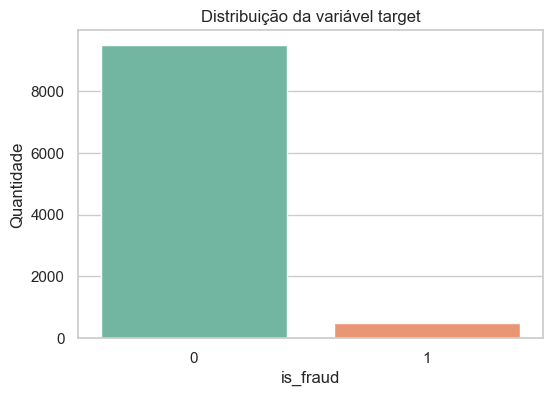

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_fraud", hue="is_fraud", palette="Set2", legend=False)
plt.title("Distribuição da variável target")
plt.xlabel("is_fraud")
plt.ylabel("Quantidade")
plt.show()

In [13]:
categorical_columns = ["transaction_type", "merchant_category", "country"]

for column in categorical_columns:
    display(df[column].value_counts().to_frame("quantidade"))

,quantidade
transaction_type,
POS,2568
ATM,2529
QR,2506
Online,2397


,quantidade
merchant_category,
Food,2023
Travel,2015
Electronics,2007
Clothing,1982
Grocery,1973


,quantidade
country,
US,2050
FR,2027
UK,1965
DE,1930
TR,1928
NG,100


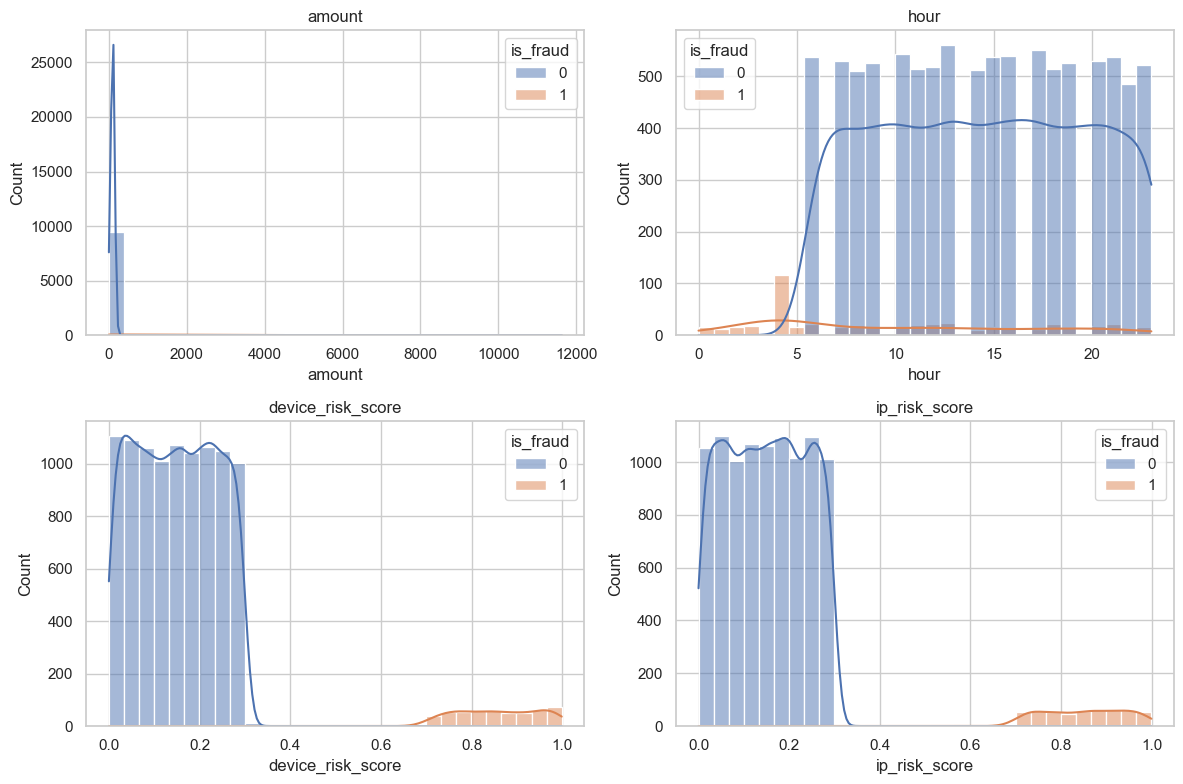

In [14]:
numeric_columns_preview = ["amount", "hour", "device_risk_score", "ip_risk_score"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, column in zip(axes, numeric_columns_preview):
    sns.histplot(data=df, x=column, hue="is_fraud", bins=30, kde=True, ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

## 4. Definição do problema

A variável alvo é `is_fraud`, que indica se a transação é fraudulenta.

As colunas `transaction_id` e `user_id` foram removidas porque funcionam como identificadores e não representam atributos gerais da transação para inferência.

In [15]:
target_column = "is_fraud"
id_columns = ["transaction_id", "user_id"]

X = df.drop(columns=[target_column] + id_columns)
y = df[target_column]

X.head()

,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score
0,4922.587542,ATM,Travel,TR,12,0.992347,0.947908
1,48.018303,QR,Food,US,21,0.168571,0.224057
2,136.881960,Online,Travel,TR,14,0.296127,0.125058
3,80.534719,POS,Clothing,TR,23,0.124801,0.159243
4,120.041158,Online,Grocery,FR,16,0.098129,0.027542


## 5. Separação em treino e teste

A separação é estratificada para preservar a proporção entre fraudes e não fraudes nos conjuntos de treino e teste.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Proporção treino/teste: {1 - TEST_SIZE:.0%} / {TEST_SIZE:.0%}")
print("Treino:", X_train.shape)
print(y_train.value_counts().sort_index())
print("\nTeste:", X_test.shape)
print(y_test.value_counts().sort_index())

Proporção treino/teste: 80% / 20%
Treino: (8000, 7)
is_fraud
0    7600
1     400
Name: count, dtype: int64

Teste: (2000, 7)
is_fraud
0    1900
1     100
Name: count, dtype: int64


## 6. Pre-processamento

O pipeline trata valores ausentes, padroniza variáveis numericas e aplica one-hot encoding nas variáveis categóricas.

In [17]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", encoder),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Features numericas:", numeric_features)
print("Features categóricas:", categorical_features)
print("Formato depois do pre-processamento:", X_train_processed.shape)

Features numericas: ['amount', 'hour', 'device_risk_score', 'ip_risk_score']
Features categóricas: ['transaction_type', 'merchant_category', 'country']
Formato depois do pre-processamento: (8000, 19)


C:\Users\Vitor\AppData\Local\Temp\ipykernel_34316\1113584588.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


## 7. Balanceamento do treino

Como fraudes representam uma parcela pequena da base, o conjunto de treino é balanceado por oversampling simples da classe minoritária. O teste permanece sem balanceamento para simular a distribuição real dos dados.

In [18]:
def oversample_minority_class(X_data, y_data, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    y_array = np.asarray(y_data)

    classes, counts = np.unique(y_array, return_counts=True)
    majority_count = counts.max()

    sampled_indices = []
    for class_value in classes:
        class_indices = np.flatnonzero(y_array == class_value)
        extra_indices = rng.choice(
            class_indices,
            size=majority_count - len(class_indices),
            replace=True,
        )
        sampled_indices.extend(class_indices.tolist())
        sampled_indices.extend(extra_indices.tolist())

    sampled_indices = np.array(sampled_indices)
    rng.shuffle(sampled_indices)

    return X_data[sampled_indices], y_array[sampled_indices]

X_train_balanced, y_train_balanced = oversample_minority_class(X_train_processed, y_train)

pd.Series(y_train_balanced).value_counts().sort_index()

0    7600
1    7600
Name: count, dtype: int64

## 8. Modelo de rede neural

In [19]:
neural_network = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_STATE,
)

neural_network.fit(X_train_balanced, y_train_balanced)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## 9. Avaliação do modelo

In [20]:
y_pred = neural_network.predict(X_test_processed)

metrics = {
    "acurácia": accuracy_score(y_test, y_pred),
    "precisão": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1_score": f1_score(y_test, y_pred, zero_division=0),
}

pd.DataFrame([metrics]).round(4)

,acurácia,precisão,recall,f1_score
0,1.0,1.0,1.0,1.0


In [21]:
print(classification_report(y_test, y_pred, target_names=["Não fraude", "Fraude"], zero_division=0))

              precision    recall  f1-score   support

  Não fraude       1.00      1.00      1.00      1900
      Fraude       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



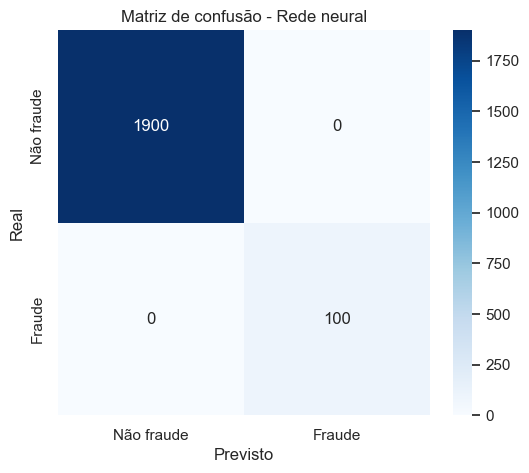

In [22]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Não fraude", "Fraude"],
    yticklabels=["Não fraude", "Fraude"],
)
plt.title("Matriz de confusão - Rede neural")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## 10. Interpretação inicial

Acurácia isolada pode ser enganosa neste problema porque a classe fraude é minoritária. Por isso, o resultado deve ser interpretado junto com recall e F1-score.

- Recall alto para fraude significa que o modelo identifica mais transações fraudulentas.
- Precisão alta para fraude significa que, quando o modelo alerta fraude, ele erra menos.
- F1-score equilibra precisão e recall.

In [23]:
results = pd.DataFrame([
    {"modelo": "Rede Neural (MLP)", **metrics}
])

results.round(4)

,modelo,acurácia,precisão,recall,f1_score
0,Rede Neural (MLP),1.0,1.0,1.0,1.0


## 11. TODO - Classificadores individuais

Adicionar pelo menos mais dois classificadores individuais para cumprir o requisito mínimo de 3 modelos. Sugestões:

- KNN
- Naive Bayes
- SVM
- Árvore de Decisão

Cada modelo deve ser treinado e avaliado separadamente usando as mesmas métricas.

## 12. Modelo de Árvore de Decisão

Nesta etapa, treinamos um modelo de Árvore de Decisão. Utilizamos o parâmetro max_depth para limitar a profundidade da árvore, o que ajuda a evitar o overfitting aos dados de treino e mantém o modelo interpretável.

In [24]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5)
decision_tree.fit(X_train_balanced, y_train_balanced)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## 13. Avaliação do Modelo


In [25]:
y_pred_dt = decision_tree.predict(X_test_processed)

metrics_dt = {
    "acurácia": accuracy_score(y_test, y_pred_dt),
    "precisão": precision_score(y_test, y_pred_dt, zero_division=0),
    "recall": recall_score(y_test, y_pred_dt, zero_division=0),
    "f1_score": f1_score(y_test, y_pred_dt, zero_division=0),
}

print("Métricas - Árvore de Decisão:")
display(pd.DataFrame([metrics_dt]).round(4))

print("\\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_dt, target_names=["Não fraude", "Fraude"], zero_division=0))

Métricas - Árvore de Decisão:


,acurácia,precisão,recall,f1_score
0,1.0,1.0,1.0,1.0


\nRelatório de Classificação:
              precision    recall  f1-score   support

  Não fraude       1.00      1.00      1.00      1900
      Fraude       1.00      1.00      1.00       100

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



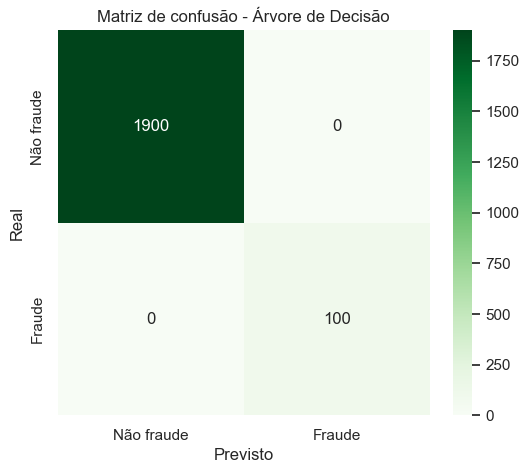

In [26]:
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_dt,
    annot=True,
    fmt="d",
    cmap="Greens", # Usando verde para diferenciar da matriz da Rede Neural
    xticklabels=["Não fraude", "Fraude"],
    yticklabels=["Não fraude", "Fraude"],
)
plt.title("Matriz de confusão - Árvore de Decisão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [27]:
results = pd.concat([
    results,
    pd.DataFrame([{"modelo": "Árvore de Decisão", **metrics_dt}])
], ignore_index=True)

display(results.round(4))

,modelo,acurácia,precisão,recall,f1_score
0,Rede Neural (MLP),1.0,1.0,1.0,1.0
1,Árvore de Decisão,1.0,1.0,1.0,1.0


In [19]:
# TODO: treinar e avaliar KNN
# TODO: treinar e avaliar Naive Bayes
# TODO: treinar e avaliar SVM ou Árvore de Decisão

## 13. TODO - Comitê de classificadores

Construir o ensemble combinando os classificadores por votação majoritária ou votação ponderada. Depois, comparar o resultado do comitê com os modelos individuais.

In [20]:
# TODO: criar VotingClassifier com os modelos individuais
# TODO: avaliar o comitê com acurácia, precisão, recall, F1-score e matriz de confusão
# TODO: comparar os resultados em uma tabela final

## 14. TODO - Discussão e conclusão

Pontos para desenvolver no relatório:

- o modelo conseguiu identificar fraudes de forma satisfatória?
- qual métrica é mais importante para este problema?
- o desbalanceamento influenciou o desempenho?
- quais melhorias poderiam ser feitas no futuro?